## **Project 1**



Importing the neccessary Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix
)
from sklearn.model_selection import cross_val_score, GridSearchCV

***Part 1: Load the dataset***

In [4]:
df1=pd.read_csv("historical_stocks.csv")
df2= pd.read_csv("historical_stock_prices.csv")

***understanding the dataset***
In this part, I will import the necessary libraries, including Pandas, NumPy, and Matplotlib, and load the datasets into the notebook. I will use head() to display the first five rows of each dataset and get an initial understanding of the data and its attributes. I will also use shape to identify the number of rows and columns and info() to examine the data types, non-null values, and overall structure of each dataset. These steps will help identify any potential data quality issues before proceeding with data cleaning and analysis.

In [5]:
df1.head()

,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


This datasets has the following:
Ticker: The unique stock symbol used to identify the company
Exchange: The stock exchange where the company is listed.
Name: The full name of the company.
Sector: The broad category of the companys business such as Finance, Consumer Services.
Industry: Representing a more specific classification of the companys business activities.

In [6]:
df2.head()

,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


This dataset has the following attributes:
Ticker: The unique stock symbol used to identify the company
Open: The stock price at the beginning of the trading day.
Close: The stock price at the end of the trading day.
Adj_close: The adjusted closing price, accounting for events such as dividends or stock splits.
Low: The lowest price reached during the trading day.
High: The highest price reached during the trading day.
Volume: The number of shares traded during the day.
Date: The date of the trading activity.

Using df.head()
Displays the first 5 rows of the dataset, providing a quick view of the data and its values.


Based on these two datasets, they are related through the ticker column, which identifies each company.
The first dataset provides company information, such as the company name, exchange, sector, and industry while the second dataset provides daily stock market information, such as opening price, closing price, high, low, and trading volume.

In [7]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ticker    6460 non-null   str  
 1   exchange  6460 non-null   str  
 2   name      6460 non-null   str  
 3   sector    5020 non-null   str  
 4   industry  5020 non-null   str  
dtypes: str(5)
memory usage: 252.5 KB


Using df.info()
Provides a summary of the dataset, including the total number of columns, data types, and non-null values.

Based on this details, the ticker, exchange, and name columns have no missing values, while sector and industry each have 1,440 (6460-5020) missing values that may need to be addressed during data cleaning. Also, the entire dataset is made up of text or categorical variables. Note that the info information for this dataset did not provide the null value of the dataset because it is too huge

In [10]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     str    
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date       str    
dtypes: float64(5), int64(1), str(2)
memory usage: 1.3 GB


The dataset has 20,973,889 rows and 8 columns. It contains 5 numerical columns (float64), 1 integer column (int64), and 2 string columns (str). The date column is currently stored as a string but it should be datetime as no date is a text or string. 

In [11]:
df2.isnull().sum()

ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64

Using the isnull() function, I checked the dataset for missing values. The results show that there are no missing values in the dataset.

In [8]:
df1.shape

(6460, 5)

In [9]:
df2.shape

(20973889, 8)

Using df.shape
Shows the number of rows and columns in the dataset, helping to understand its overall size. The first dataset has a total of 6460 rows and 5 columns while datset 2 has a total of 20,973,889 rows and 8 columns.

***Part 2: Check Data Quality***

Checking for missing values

In [13]:
df1.isnull().sum()

ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

In [14]:
df2.isnull().sum()

ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64

Note that missing values are not necessary errors, they occur because information was not collected, was not applicable, or was unavailable. 

Check for duplicated values

In [15]:
df1.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6455    False
6456    False
6457    False
6458    False
6459    False
Length: 6460, dtype: bool

In [16]:
df2.duplicated()

0           False
1           False
2           False
3           False
4           False
            ...  
20973884    False
20973885    False
20973886    False
20973887    False
20973888    False
Length: 20973889, dtype: bool

 The duplicated() function checked each row to see if it was an exact duplicate of a previous row. Based on the output for both dataset there is no duplicated rows. However, because the dataset 2 is huge. i will be specifying two columns to make suce there are no duplicated


In [18]:
df2.duplicated(subset=['ticker', 'date']).sum()

np.int64(0)

The output still shows that there is no duplicates. 

Based on the data exploration and cleaning steps, the main issues identified are the incorrect data type for the date column in Dataset 2 and missing values in some attributes of Dataset 1. The missing values will be handled using appropriate methods such as mean, median, or K-Nearest Neighbours (KNN) imputation.

***Prepare and Explore the Date***

In [19]:
#converting date datatype from string to datetime
df2['date'] = pd.to_datetime(df2['date'])

In [20]:
#verify the changes
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   ticker     str           
 1   open       float64       
 2   close      float64       
 3   adj_close  float64       
 4   low        float64       
 5   high       float64       
 6   volume     int64         
 7   date       datetime64[us]
dtypes: datetime64[us](1), float64(5), int64(1), str(1)
memory usage: 1.3 GB


The changes have been applied: changing data type from string to datetime

In [21]:
#find the minimum and maximum date and verify the changes
df2['date'].min()
df2['date'].max()
print("Minimum date:", df2['date'].min())
print("Maximum date:", df2['date'].max())


Minimum date: 1970-01-02 00:00:00
Maximum date: 2018-08-24 00:00:00


Converting dates from strings to datetime makes it easier to sort, compare, and manipulate dates. Datetime values are also useful for time-series analysis.

In [23]:
df1['ticker'].is_unique

True

In the historical stocks dataset, all the ticker's are unique, meaning that each corresponds to a particular trasaction/period. Again confirming there are no duplicated.

In [24]:
df2['ticker'].is_unique

False

This return a fasle meaning that there are duplicate in the ticker column. This is expected because each company has many daily stock records with the Ticker as ID however to know if there are really duplicates, i will combine two coulmn together to search the unique values based on that. This will give a true and clear picture because, there could be duplicate in the ticker columns but if we read the whole transaction for the period, it might show otherwise. I will also verify the number of false unique.

In [25]:
#displaying the rows with duplicated tickers
df2[df2['ticker'].duplicated(keep=False)]

,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14
...,...,...,...,...,...,...,...,...
20973884,NZF,14.60,14.59,14.590000,14.58,14.62,137500,2018-08-20
20973885,NZF,14.60,14.58,14.580000,14.57,14.61,151200,2018-08-21
20973886,NZF,14.58,14.59,14.590000,14.57,14.63,185400,2018-08-22
20973887,NZF,14.60,14.57,14.570000,14.57,14.64,135600,2018-08-23


In [26]:
#combinding ticker and dates. as above but this time generating the sum of the duplicates if any
df2.duplicated(subset=['ticker', 'date']).sum()

np.int64(0)

No duplicates values.

***Exploring Categorical Data***


*** dataset 1 -histiorical stocks

In [27]:
df1['exchange'].value_counts()

exchange
NASDAQ    3308
NYSE      3152
Name: count, dtype: int64

This shows the type and number of securities  for each exchange

In [28]:
exchange_counts = df1['exchange'].value_counts().reset_index()
exchange_counts.columns = ['Exchange', 'Number of Securities']

print(exchange_counts)

  Exchange  Number of Securities
0   NASDAQ                  3308
1     NYSE                  3152


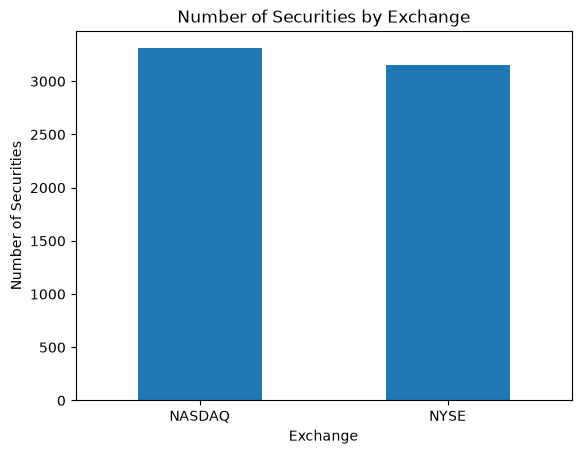

In [29]:
#generating a bar shat to visualize the number of securities for each exchange
exchange_counts = df1['exchange'].value_counts()

exchange_counts.plot(kind='bar')

plt.title('Number of Securities by Exchange')
plt.xlabel('Exchange')
plt.ylabel('Number of Securities')
plt.xticks(rotation=0)
plt.show()

There are just two securities( Nasdaq and NYSE) both are relatively evenly distributed. however, NASDAQ has slightly more securities than NYSE, with a difference of 156 securities.

In [32]:
#doing the same for the sector attributes. verifying the distribution of sector based on the number of securities
df1['sector'].value_counts()

sector
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
SECTOR                      1
Name: count, dtype: int64

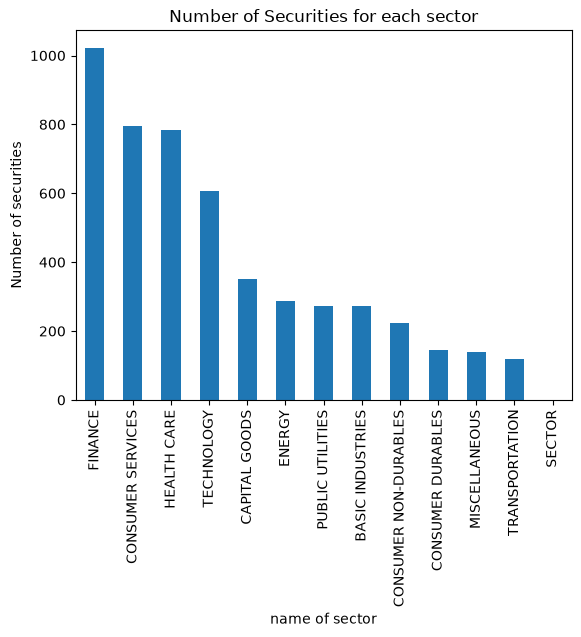

In [38]:
df1['sector'].value_counts().plot(kind='bar')
plt.title('Number of Securities for each sector')
plt.xlabel('name of sector')
plt.ylabel('Number of securities')
plt.xticks(rotation=90)
plt.show()

Note that sector column had 1,440 missing values, which has not yet been taken care of. So, those rows will not be included in value_counts()

In [39]:
df1['sector'].nunique()

13

In [51]:
df2['ticker'].nunique()

5685

In [55]:
df1['ticker'].nunique()

6460

In [56]:
df1['ticker'].is_unique

True

In [53]:
#how many of the tickers in the metadata have prives
df1['ticker'].isin(df2['ticker']).value_counts()

ticker
True     5685
False     775
Name: count, dtype: int64

This means that the there are 775 tickers with no prices

In [67]:
#check which tickers don't have prices
df1.loc[df1['ticker'].isin(df2['ticker']),'ticker'].head(10)

0       PIH
1     PIHPP
2      TURN
3      FLWS
4      FCCY
5      SRCE
6      VNET
7      TWOU
8      JOBS
10     AVHI
Name: ticker, dtype: str

The above tickers have no prices.

In [68]:
df1[df1['ticker']=='Symbol']

,ticker,exchange,name,sector,industry
74,Symbol,NYSE,NAME,SECTOR,INDUSTRY


In [70]:
df1.loc[df1['ticker'].isin(df2['ticker'])].head(10)

,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS
5,SRCE,NASDAQ,1ST SOURCE CORPORATION,FINANCE,MAJOR BANKS
6,VNET,NASDAQ,"21VIANET GROUP, INC.",TECHNOLOGY,"COMPUTER SOFTWARE: PROGRAMMING, DATA PROCESSING"
7,TWOU,NASDAQ,"2U, INC.",TECHNOLOGY,COMPUTER SOFTWARE: PREPACKAGED SOFTWARE
8,JOBS,NASDAQ,"51JOB, INC.",TECHNOLOGY,DIVERSIFIED COMMERCIAL SERVICES
10,AVHI,NASDAQ,"A V HOMES, INC.",CAPITAL GOODS,HOMEBUILDING


The symbol ticker seems to be an error or a partial header that was made a column.

In [71]:
df1['sector'].value_counts(dropna=False)

sector
NaN                      1440
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
SECTOR                      1
Name: count, dtype: int64

the sector has just one value which represent the symbol. At soem point we will drop this column

***Part 5 — Explore Numerical Data***
Explore these variables:
• open
• high
• low
• close
• volume

In [42]:

#Check for teh missing values in this variables
df2[['open', 'high', 'low', 'close', 'volume']].isnull().sum()

open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [43]:
#use the describe function to find the mean, median, count, maximum and minimum
df2[['open', 'high', 'low', 'close', 'volume']].describe()

,open,high,low,close,volume
count,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07
mean,7.605823e+01,7.803857e+01,7.422064e+01,7.611403e+01,1.227043e+06
std,2.849639e+03,2.997937e+03,2.746059e+03,2.870159e+03,1.316686e+07
min,4.000000e-04,4.000000e-04,1.000000e-04,2.000000e-04,1.000000e+00
25%,7.500000e+00,7.630000e+00,7.360000e+00,7.500000e+00,2.210000e+04
50%,1.545000e+01,1.566000e+01,1.524000e+01,1.545000e+01,1.260000e+05
75%,2.972000e+01,3.010000e+01,2.928000e+01,2.972000e+01,6.074000e+05
max,2.034000e+06,2.070000e+06,1.440000e+06,1.779750e+06,4.483504e+09


remove the exponentials

In [77]:
pd.set_option('display.float_format', '{:,.2f}'.format)

df2[['open', 'high', 'low', 'close', 'volume']].describe()

,open,high,low,close,volume
count,"20,973,889.00","20,973,889.00","20,973,889.00","20,973,889.00","20,973,889.00"
mean,76.06,78.04,74.22,76.11,"1,227,043.03"
std,"2,849.64","2,997.94","2,746.06","2,870.16","13,166,864.47"
min,0.00,0.00,0.00,0.00,1.00
25%,7.50,7.63,7.36,7.50,"22,100.00"
50%,15.45,15.66,15.24,15.45,"126,000.00"
75%,29.72,30.10,29.28,29.72,"607,400.00"
max,"2,034,000.00","2,070,000.00","1,440,000.00","1,779,750.00","4,483,504,400.00"


mean closing price is $76.11.
median closing price is $15.45.
the difference between teh mean and median are $76.11 − $15.45 = $60.66. that is mean is $60.66 higher than the median. this large difference suggests that the closing-price distribution is strongly right-skewed
the variable with the largest standard deviation is volume with Volume = 13,166,864.47

***Part 6 — Investigate Unusual Values***

In [79]:
highest_close = df2.nlargest(10, 'close')

print(highest_close[['ticker', 'date', 'open', 'high', 'low', 'close','volume']])

         ticker       date         open         high          low  \
12146443   SCON 2000-02-28 1,395,000.00 1,797,750.00 1,368,000.00   
12146459   SCON 2000-02-29 2,034,000.00 2,070,000.00 1,440,000.00   
12146546   SCON 2000-03-13   900,000.00 1,404,000.00   861,750.00   
17889354   CODA 2001-02-05 1,354,500.00 1,736,700.00 1,354,500.00   
2444619    TVIX 2013-02-26 1,375,000.00 1,542,500.00 1,300,000.00   
12146480   SCON 2000-03-02 1,120,500.00 1,368,000.00 1,098,280.75   
12146437   SCON 2000-02-25   873,561.62 1,369,125.00   873,000.00   
17107201   TOPS 2016-08-01   783,000.00 1,276,200.00   783,000.00   
12146465   SCON 2000-03-01 1,368,000.00 1,512,000.00 1,107,000.00   
12146562   SCON 2000-03-14 1,352,250.00 1,354,500.00 1,080,000.00   

                close  volume  
12146443 1,779,750.00     400  
12146459 1,595,250.00     400  
12146546 1,363,500.00     300  
17889354 1,354,500.00      34  
2444619  1,347,500.00     100  
12146480 1,261,125.00     200  
12146437 1,215,0

CON reached the highest closing price of $1,779,750 on February 28, 2000 and SCON continued to show high prices over several trading days, suggesting these are not simply one isolated observation. These values are significantly higher than the median closing price of $15.45 ($1,779,750.00 − $15.45).

the trading volume for this security is 400

In [80]:
#verify if the high prices are all across SCON
scon = df2[df2['ticker'] == 'SCON']

print(scon[['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']])

         ticker       date       open       high        low      close  volume
12146372   SCON 2000-02-16 500,625.00 621,000.00 387,000.00 555,750.00     500
12146378   SCON 2000-02-17 700,875.00 819,000.00 653,625.00 721,125.00     400
12146393   SCON 2000-02-18 666,000.00 666,000.00 576,000.00 605,250.00     100
12146400   SCON 2000-02-22 667,125.00 717,750.00 625,500.00 641,250.00     100
12146415   SCON 2000-02-23 686,250.00 882,000.00 648,000.00 848,250.00     200
...         ...        ...        ...        ...        ...        ...     ...
12192119   SCON 2018-08-20       2.48       2.48       2.25       2.38  119000
12192139   SCON 2018-08-21       2.36       2.40       2.23       2.27   54100
12192145   SCON 2018-08-22       2.35       2.40       2.28       2.35   53000
12192146   SCON 2018-08-23       2.30       2.35       2.27       2.31   44800
12192147   SCON 2018-08-24       2.29       2.39       2.27       2.31   53900

[1939 rows x 7 columns]


The SCON records show unusually high prices during February 2000, with the closing price reaching $1,779,750 on February 28, 2000. The prices gradually decrease over the following months and are much lower in later years, reaching approximately $2–$3 in 2018.

In [81]:
#verify the describe function with just teh SCON
scon[['open', 'high', 'low', 'close', 'volume']].describe()

,open,high,low,close,volume
count,"1,939.00","1,939.00","1,939.00","1,939.00","1,939.00"
mean,"15,263.40","17,282.19","13,759.89","15,656.23","14,982.83"
std,"102,427.58","117,891.96","88,271.11","104,025.15","98,524.35"
min,2.08,2.35,1.47,2.11,100.00
25%,24.00,25.30,23.00,23.90,200.00
50%,327.00,334.50,312.00,324.00,800.00
75%,"3,771.00","4,014.00","3,330.00","3,789.00","5,550.00"
max,"2,034,000.00","2,070,000.00","1,440,000.00","1,779,750.00","2,832,900.00"


In [82]:
#check whether the price sudenly changes
scon = scon.sort_values('date')

print(scon[['date', 'open', 'high', 'low', 'close']].head(20))

               date         open         high          low        close
12146372 2000-02-16   500,625.00   621,000.00   387,000.00   555,750.00
12146378 2000-02-17   700,875.00   819,000.00   653,625.00   721,125.00
12146393 2000-02-18   666,000.00   666,000.00   576,000.00   605,250.00
12146400 2000-02-22   667,125.00   717,750.00   625,500.00   641,250.00
12146415 2000-02-23   686,250.00   882,000.00   648,000.00   848,250.00
12146421 2000-02-24   830,250.00   905,905.81   733,500.00   843,750.00
12146437 2000-02-25   873,561.62 1,369,125.00   873,000.00 1,215,000.00
12146443 2000-02-28 1,395,000.00 1,797,750.00 1,368,000.00 1,779,750.00
12146459 2000-02-29 2,034,000.00 2,070,000.00 1,440,000.00 1,595,250.00
12146465 2000-03-01 1,368,000.00 1,512,000.00 1,107,000.00 1,134,000.00
12146480 2000-03-02 1,120,500.00 1,368,000.00 1,098,280.75 1,261,125.00
12146500 2000-03-06 1,222,875.00 1,222,875.00   885,375.00   895,500.00
12146506 2000-03-07   900,000.00 1,065,936.62   859,500.00   997

there was a sudden increase in this section was from Feb 25 to Feb 28 of %848,250.00 to $1,779,750, indicating a closing price increased by approximately 46.5%. This don't seem to be an erro, just changes in market circumstances

***Adjusted Closing Price***

In [83]:
#Find the largest adjusted closing values
highest_adj_close = df2.nlargest(10, 'adj_close')

print(highest_adj_close[
    ['ticker', 'date', 'close', 'adj_close']
])

        ticker       date  close                     adj_close
6174033    AAN 1987-02-27   1.30 18,949,618,910,812,401,664.00
6174039    AAN 1987-03-10   1.30 18,949,618,910,812,401,664.00
6174040    AAN 1987-03-11   1.30 18,949,618,910,812,401,664.00
6174041    AAN 1987-03-12   1.30 18,949,618,910,812,401,664.00
6174044    AAN 1987-03-17   1.30 18,949,618,910,812,401,664.00
6174045    AAN 1987-03-18   1.30 18,949,618,910,812,401,664.00
6174046    AAN 1987-03-19   1.30 18,949,618,910,812,401,664.00
6174049    AAN 1987-03-25   1.30 18,949,618,910,812,401,664.00
6174051    AAN 1987-03-27   1.29 18,814,275,626,503,000,064.00
6174050    AAN 1987-03-26   1.27 18,543,558,271,558,500,352.00


In [84]:
#compare the close price and the adj close price
highest_adj_close['difference'] = (
    highest_adj_close['adj_close'] - highest_adj_close['close']
)

print(highest_adj_close[
    ['ticker', 'date', 'close', 'adj_close', 'difference']
])

        ticker       date  close                     adj_close  \
6174033    AAN 1987-02-27   1.30 18,949,618,910,812,401,664.00   
6174039    AAN 1987-03-10   1.30 18,949,618,910,812,401,664.00   
6174040    AAN 1987-03-11   1.30 18,949,618,910,812,401,664.00   
6174041    AAN 1987-03-12   1.30 18,949,618,910,812,401,664.00   
6174044    AAN 1987-03-17   1.30 18,949,618,910,812,401,664.00   
6174045    AAN 1987-03-18   1.30 18,949,618,910,812,401,664.00   
6174046    AAN 1987-03-19   1.30 18,949,618,910,812,401,664.00   
6174049    AAN 1987-03-25   1.30 18,949,618,910,812,401,664.00   
6174051    AAN 1987-03-27   1.29 18,814,275,626,503,000,064.00   
6174050    AAN 1987-03-26   1.27 18,543,558,271,558,500,352.00   

                           difference  
6174033 18,949,618,910,812,401,664.00  
6174039 18,949,618,910,812,401,664.00  
6174040 18,949,618,910,812,401,664.00  
6174041 18,949,618,910,812,401,664.00  
6174044 18,949,618,910,812,401,664.00  
6174045 18,949,618,910,812,401,66


The largest adjusted closing values in your results are all for AAN with an adjusted closing price of about 18.95 qunatile while the actual closing price is about 1.30. There are huge difference in comparing the close price and the adjusted close price for the 10 largest prices. close prices are around $1.27–$1.30, but the adj_close values are approximately $18,949,618,910,812,401,664

The unusual values occur in 1987. Again, this could be an error or a change in circumstances not necessarily an error. for now i would not delete them or try to standardize them

In [85]:
#are the unsul values concentrated around certain periods?
print(
    highest_adj_close[
        ['ticker', 'date', 'close', 'adj_close']
    ].sort_values('date')
)

        ticker       date  close                     adj_close
6174033    AAN 1987-02-27   1.30 18,949,618,910,812,401,664.00
6174039    AAN 1987-03-10   1.30 18,949,618,910,812,401,664.00
6174040    AAN 1987-03-11   1.30 18,949,618,910,812,401,664.00
6174041    AAN 1987-03-12   1.30 18,949,618,910,812,401,664.00
6174044    AAN 1987-03-17   1.30 18,949,618,910,812,401,664.00
6174045    AAN 1987-03-18   1.30 18,949,618,910,812,401,664.00
6174046    AAN 1987-03-19   1.30 18,949,618,910,812,401,664.00
6174049    AAN 1987-03-25   1.30 18,949,618,910,812,401,664.00
6174050    AAN 1987-03-26   1.27 18,543,558,271,558,500,352.00
6174051    AAN 1987-03-27   1.29 18,814,275,626,503,000,064.00


In [90]:
print(
    highest_adj_close[
        ['ticker', 'date', 'close', 'adj_close']
    ].sort_values('date', ascending=False)
)

        ticker       date  close                     adj_close
6174051    AAN 1987-03-27   1.29 18,814,275,626,503,000,064.00
6174050    AAN 1987-03-26   1.27 18,543,558,271,558,500,352.00
6174049    AAN 1987-03-25   1.30 18,949,618,910,812,401,664.00
6174046    AAN 1987-03-19   1.30 18,949,618,910,812,401,664.00
6174045    AAN 1987-03-18   1.30 18,949,618,910,812,401,664.00
6174044    AAN 1987-03-17   1.30 18,949,618,910,812,401,664.00
6174041    AAN 1987-03-12   1.30 18,949,618,910,812,401,664.00
6174040    AAN 1987-03-11   1.30 18,949,618,910,812,401,664.00
6174039    AAN 1987-03-10   1.30 18,949,618,910,812,401,664.00
6174033    AAN 1987-02-27   1.30 18,949,618,910,812,401,664.00


The unusual values seems tobe through out the dataset and no specific period of high adj_ closing price. 

In [91]:
#compare the distribution of the largest values
print("Largest Close:")
print(df2.nlargest(10, 'close')[['ticker', 'date', 'close']])

print("\nLargest Adjusted Close:")
print(df2.nlargest(10, 'adj_close')[['ticker', 'date', 'adj_close']])

Largest Close:
         ticker       date        close
12146443   SCON 2000-02-28 1,779,750.00
12146459   SCON 2000-02-29 1,595,250.00
12146546   SCON 2000-03-13 1,363,500.00
17889354   CODA 2001-02-05 1,354,500.00
2444619    TVIX 2013-02-26 1,347,500.00
12146480   SCON 2000-03-02 1,261,125.00
12146437   SCON 2000-02-25 1,215,000.00
17107201   TOPS 2016-08-01 1,189,800.00
12146465   SCON 2000-03-01 1,134,000.00
12146562   SCON 2000-03-14 1,111,500.00

Largest Adjusted Close:
        ticker       date                     adj_close
6174033    AAN 1987-02-27 18,949,618,910,812,401,664.00
6174039    AAN 1987-03-10 18,949,618,910,812,401,664.00
6174040    AAN 1987-03-11 18,949,618,910,812,401,664.00
6174041    AAN 1987-03-12 18,949,618,910,812,401,664.00
6174044    AAN 1987-03-17 18,949,618,910,812,401,664.00
6174045    AAN 1987-03-18 18,949,618,910,812,401,664.00
6174046    AAN 1987-03-19 18,949,618,910,812,401,664.00
6174049    AAN 1987-03-25 18,949,618,910,812,401,664.00
6174051    AAN 1

the recent years have high closing prices concentarted aorund the SCON while the later years had high adjusted closing prices concentrated around the ANN

***Part7 Closing Visualization***

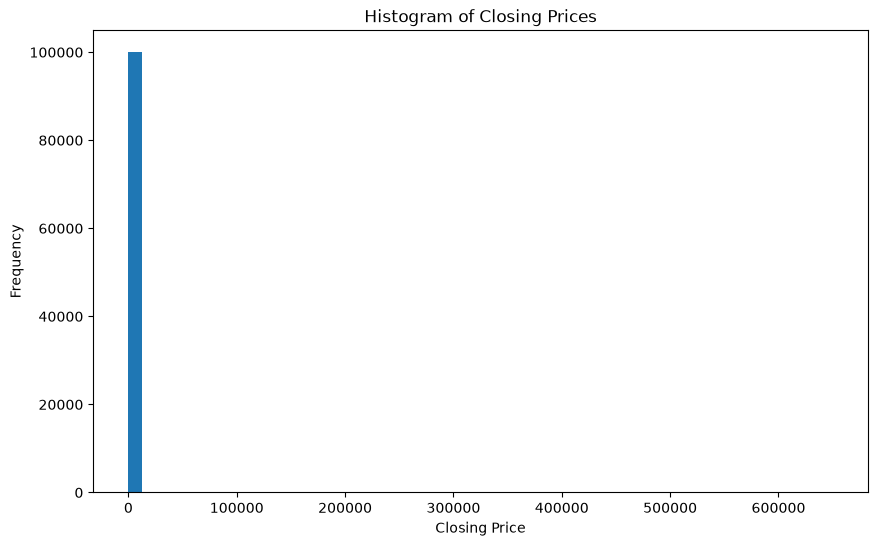

In [92]:
#Closing Price Histogram
sample = df2['close'].sample(100000, random_state=42)

plt.figure(figsize=(10, 6))
plt.hist(sample, bins=50)
plt.title('Histogram of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

Tipically, the closing prices are around 1.3

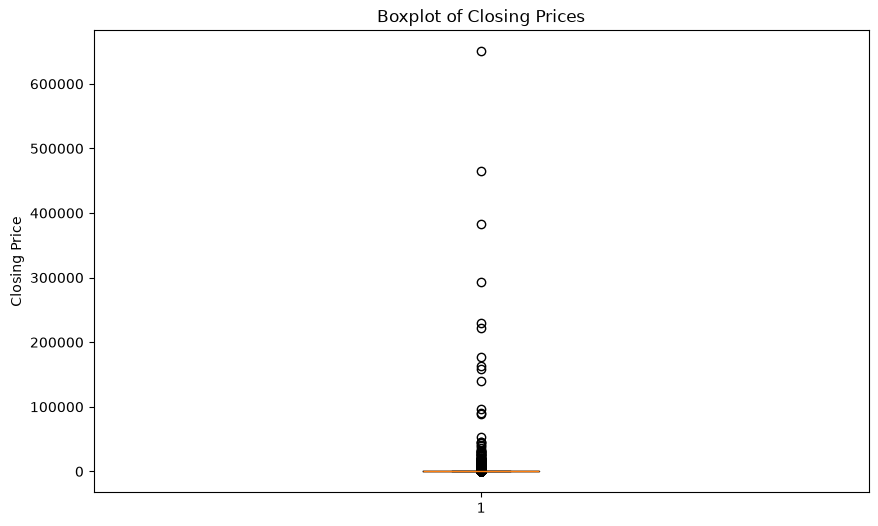

In [93]:
#closing prices boxplots to verify outliers
sample_close = df2['close'].sample(100000, random_state=42)

plt.figure(figsize=(10, 6))
plt.boxplot(sample_close)
plt.title('Boxplot of Closing Prices')
plt.ylabel('Closing Price')
plt.show()

There is huge outliers.
Histograms and boxplots were created for closing price and trading volume. The closing price histogram shows that most observations are concentrated at relatively lower values, while a small number of extremely large values create a long right tail. The closing price boxplot also shows several potential outliers.

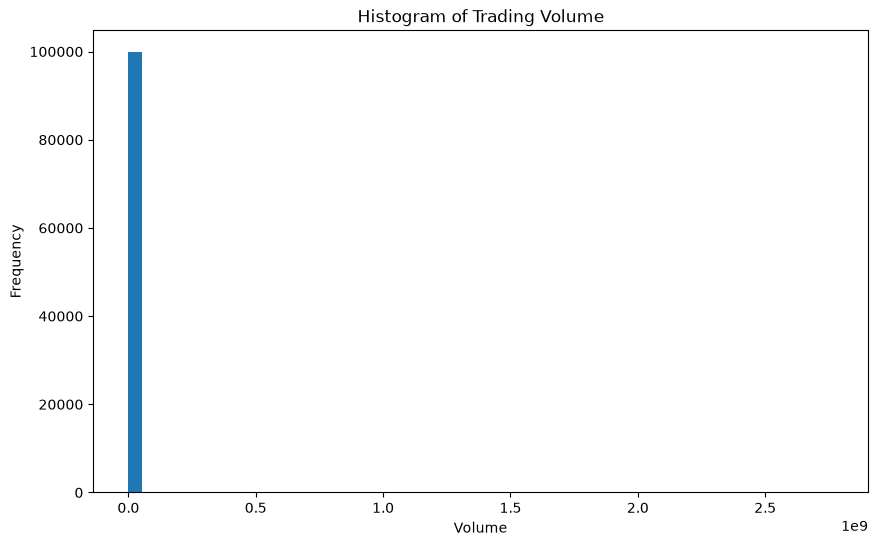

In [94]:
#volume histogram
sample_volume = df2['volume'].sample(100000, random_state=42)

plt.figure(figsize=(10, 6))
plt.hist(sample_volume, bins=50)
plt.title('Histogram of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

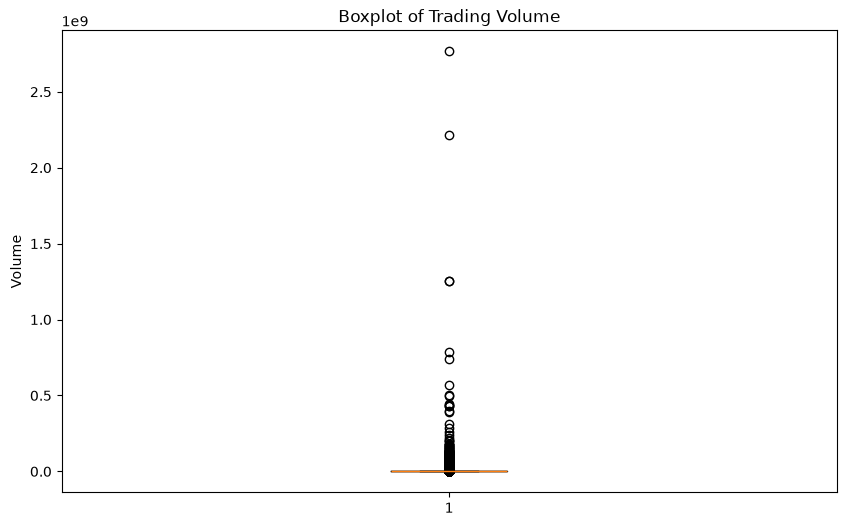

In [95]:
#Volume boxplot
sample_volume = df2['volume'].sample(100000, random_state=42)

plt.figure(figsize=(10, 6))
plt.boxplot(sample_volume)
plt.title('Boxplot of Trading Volume')
plt.ylabel('Volume')
plt.show()

The volume histogram shows that most observations have relatively low trading volume, while some observations have much higher volumes. The volume boxplot confirms the presence of high-volume outliers. These unusual observations should not automatically be removed because they may represent legitimate differences between securities or unusual market activity. Further investigation should be completed before deciding how to handle them.